In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules import data_loader, metrics, learning, plotting, utils, params, pipelines, prunning
from models.gmp import GMP
from models.leann import LEANN
import matplotlib.pyplot as plt
import numpy as np
import torch


Load data from files and init acpr meter

In [3]:
M = 6

dataset_path = "datasets/Custom_dataset"

container = data_loader.DataContainer()
container.load_data(file_path=dataset_path)
container.cut_signals(M)
container.get_gained_signals()
print(f"gain: {container.gain}")

acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )



gain: 7.750391483306885


In [4]:
frame_length = 64
batch_size = 128
batch_size_eval = 2048

# pa_train_loader, pa_val_loader = data_loader.build_dataloaders(container=container, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval)
# dla_train_loader, dla_val_loader = data_loader.build_dataloaders(container=container, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="dla")
# ila_train_loader, ila_val_loader = data_loader.build_dataloaders(container=container, frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="ila")

feature_extractor = data_loader.build_LEANN_features
pa_train_loader, pa_val_loader, pa_input_norm, pa_target_norm = data_loader.build_nn_dataloaders(container, 
                                                                                            batch_size=batch_size, 
                                                                                            batch_size_eval=batch_size_eval, 
                                                                                            arch="pa",
                                                                                            features_extractor=feature_extractor,
                                                                                            normalize_method='standard',
                                                                                            M=M)
# dla_train_loader, dla_val_loader, dla_input_norm, dla_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                                             batch_size=batch_size, 
#                                                                                             batch_size_eval=batch_size_eval,
#                                                                                             arch="dla",
#                                                                                             features_extractor=feature_extractor,
#                                                                                             normalize_method='standard',
#                                                                                             M=M)
# ila_train_loader, ila_val_loader, ila_input_norm, ila_target_norm = data_loader.build_nn_dataloaders(container, 
#                                                                                             batch_size=batch_size, 
#                                                                                             batch_size_eval=batch_size_eval,
#                                                                                             arch="ila",
#                                                                                             features_extractor=feature_extractor,
#                                                                                             normalize_method='standard',
#                                                                                             M=M)

criterion = metrics.compute_mse
metric_criterion = metrics.compute_nmse

In [5]:
class RegLoss(torch.nn.Module):
    def __init__(self, model, original_loss, lambda_reg=1e-4):
        super().__init__()
        
        self.model = model
        self.original_loss = original_loss
        self.lambda_reg = lambda_reg
        self.params = list(model.parameters())
        self.num_params = sum(p.numel() for p in self.params)
    
    def extra_loss(self, eps=1e-2):
        reg = 0.0

        for p in self.params:
            reg += torch.log10(p.pow(2) + eps).sum()

        return reg / self.num_params
    
    def forward(self, prediction, target):
        base_loss = self.original_loss(prediction, target)
        reg = self.extra_loss()
        
        return base_loss + self.lambda_reg * reg

def leann_prune(model,
                alpha=1e-3,
                tau=1e-3,
                verbose=True):
    """
    Pruning for LEANN model

    alpha — threshold for LEA weights
    tau   — threshold for FIR weights
    """

    with torch.no_grad():

        stats = {}

        # =========================
        # LEA-1 pruning
        # =========================

        w1 = model.lea_1_weight

        mask1 = torch.abs(w1) < alpha

        pruned_1 = mask1.sum().item()
        total_1 = w1.numel()

        w1[mask1] = 0.0

        stats["lea_1"] = (pruned_1, total_1)

        # =========================
        # LEA-K pruning
        # =========================

        wk = model.lea_k_weight

        maskk = torch.abs(wk) < alpha

        pruned_k = maskk.sum().item()
        total_k = wk.numel()

        wk[maskk] = 0.0

        stats["lea_k"] = (pruned_k, total_k)

        # =========================
        # FIR pruning
        # =========================

        wf = model.fir.weight

        maskf = torch.abs(wf) < tau

        pruned_f = maskf.sum().item()
        total_f = wf.numel()

        wf[maskf] = 0.0

        stats["fir"] = (pruned_f, total_f)

        # =========================
        # Reporting
        # =========================

        if verbose:

            print("\n=== LEANN PRUNING REPORT ===")

            for k, (p, t) in stats.items():

                percent = 100 * p / t

                print(
                    f"{k}: "
                    f"{p}/{t} pruned "
                    f"({percent:.2f}%)"
                )

        return stats

PA model

In [6]:
# pa_train_loader = [(x_train, y_train)]
# pa_val_loader = [(x_val, y_val)]
# pa_val_loader = pa_train_loader


pa_degree = 6
pa_config = params.make_gmp_params(
    Ka=pa_degree,
    La=pa_degree,
    Kb=pa_degree,
    Lb=pa_degree,
    Mb=pa_degree,
    Kc=pa_degree,
    Lc=pa_degree,
    Mc=pa_degree,
)

pa_model = GMP(**pa_config, model_name="pa")


print(f"total_params: {pa_model.count_params()}")

epochs = 100
lr = 0.01

optimizer = torch.optim.AdamW(pa_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not pa_model.load_weights():
      learning.train(net=pa_model, 
            criterion=criterion, 
            optimizer=optimizer, 
            train_loader=pa_train_loader, 
            val_loader=pa_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion,
            scheduler=scheduler)
      pa_model.save_weights()
utils.freeze_pa_model(pa_model)

y_val_pa = learning.net_inference(net=pa_model, x=container.val_input)
pa_nmse = metrics.compute_nmse(y_val_pa, container.val_output)
print(f"Model NMSE: {pa_nmse:.2f}")

total_params: 936
Model weights loaded from model_params/pa_GMP_Ka6_La6_Kb6_Lb6_Mb6_Kc6_Lc6_Mc6.pt
Model NMSE: -40.75


In [16]:

with torch.autograd.profiler.profile(use_cuda=False) as prof:
    with torch.no_grad():
        output = learning.net_inference(net=pa_model, x=container.val_input)

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=5))

-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                     Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
             aten::einsum         0.57%     184.100us        38.18%      12.248ms       4.083ms             3  
              aten::copy_        33.63%      10.789ms        33.63%      10.789ms     899.117us            12  
            aten::reshape         0.21%      67.400us        23.20%       7.443ms       1.240ms             6  
              aten::clone         0.13%      42.100us        22.87%       7.338ms       2.446ms             3  
                aten::mul        20.33%       6.521ms        20.33%       6.521ms       2.174ms             3  
-------------------------  ------------  ------------  ------------  ------------  ------------  -------

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


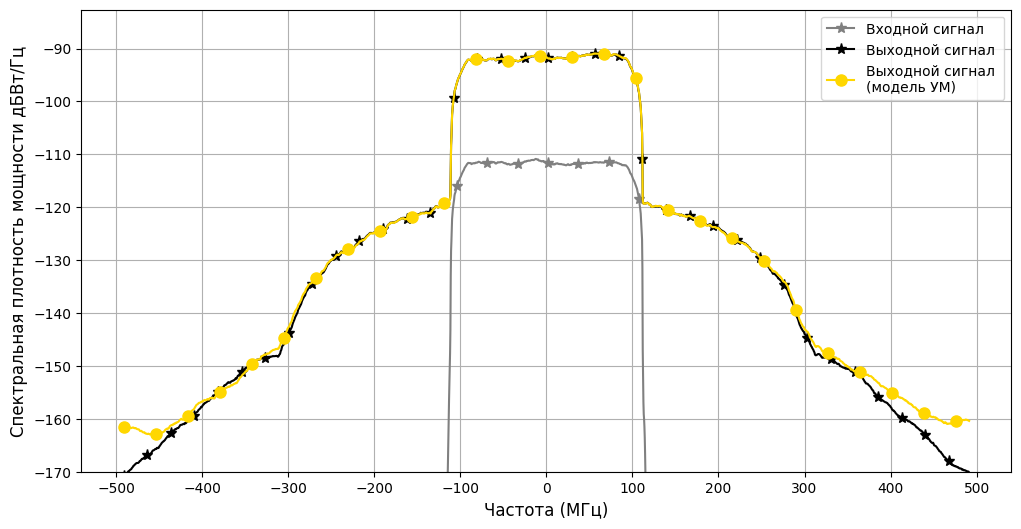

In [7]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности дБВт/Гц"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал', marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_out, color='black', label='Выходной сигнал', marker = '*', markevery=70, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал \n(модель УМ)', marker='o', markevery=95, markersize=markersize)

plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.ylim(bottom=-170)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


ILC DPD grad

In [8]:
u_k_train = learning.ilc_signal(container.train_input, container.train_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_val = learning.ilc_signal(container.val_input, container.val_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

container.ilc_train_output = u_k_train
container.ilc_val_output = u_k_val



Epoch [0/200], Loss: 0.0044437614269554615
Epoch [100/200], Loss: 8.30267197216017e-08
Epoch [199/200], Loss: 2.6492972260427905e-09
Выполнение заняло: 0:02:04
Epoch [0/200], Loss: 0.004412886220961809
Epoch [100/200], Loss: 8.248748883943335e-08
Epoch [199/200], Loss: 5.1786539466414094e-12
Выполнение заняло: 0:00:29
NMSE на выходе усилителя (ILC): -70.82 db


In [9]:
ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_nn_dataloaders(container, 
                                                                            batch_size=batch_size, 
                                                                            batch_size_eval=batch_size_eval,
                                                                            arch="ilc",
                                                                            features_extractor=feature_extractor,
                                                                            normalize_method='standard',
                                                                            M=M)

In [18]:
L1 = 16
L2 = 8
L3 = 16
K = 3

leann_model_ilc = LEANN(M=M, L2=L2, L3=L3, K=K, L1=L1, model_name="ilc")
print(f"total_params: {leann_model_ilc.count_params()}")

lr = 0.001
epochs = 300

optimizer = torch.optim.AdamW(leann_model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not leann_model_ilc.load_weights():
    learning.train(net=leann_model_ilc, 
        criterion=criterion, 
        optimizer=optimizer, 
        train_loader=ilc_train_loader, 
        val_loader=ilc_val_loader, 
        n_epochs=epochs, 
        metric_criterion=metric_criterion,
        scheduler=scheduler)
    leann_model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input_orig)
x_val_in = feature_extractor(norm_val_input, M)

y_before_pa = learning.net_inference(net=leann_model_ilc, model_type="LEANN", x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=leann_model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in, model_type="LEANN")

nmse_ilc = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {nmse_ilc:.2f}")

acpr_ilc = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {acpr_ilc[0]:.2f} {acpr_ilc[1]:.2f}")

total_params: 992
Model weights loaded from model_params/ilc_LEANN_M_6_L1_16_L2_8_L3_16_K_3.pt
Model NMSE: -48.88
Model ACPR: -61.76 -61.28


In [15]:
pleann_model = LEANN(M=M, L1=16, L2=8, L3=16, K=3, model_name="ilc_prune")
print(f"total_params: {pleann_model.count_params()}")

lr = 0.001
lr1 = 0.0001

epochs = 300
epochs1 = 200
lambda_reg = 1e-3

# compress 30%
# alpha = 0.001
# tau = 0.001

alpha = 0.001
tau = 0.001

criterion_reg = RegLoss(pleann_model, original_loss=metrics.compute_mse, lambda_reg=lambda_reg)

optimizer = torch.optim.AdamW(pleann_model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not pleann_model.load_weights():
    learning.train(net=pleann_model, 
        criterion=criterion, 
        optimizer=optimizer, 
        train_loader=ilc_train_loader, 
        val_loader=ilc_val_loader, 
        n_epochs=epochs, 
        metric_criterion=metric_criterion,
        scheduler=scheduler)
    
    optimizer = torch.optim.AdamW(pleann_model.parameters(), lr=lr1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    learning.train(net=pleann_model, 
        criterion=criterion_reg, 
        optimizer=optimizer, 
        train_loader=ilc_train_loader, 
        val_loader=ilc_val_loader, 
        n_epochs=epochs1, 
        metric_criterion=metric_criterion,
        scheduler=scheduler)
    
    leann_prune(pleann_model, alpha=alpha, tau=tau)
    
    pleann_model.save_weights()

prunning.log_layerwise_sparsity(pleann_model)

norm_val_input = pa_input_norm.transform(container.val_input_orig)
x_val_in = feature_extractor(norm_val_input, M)

casc_ilc_eval = utils.CascadeModel(model_1=pleann_model, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc_prune = learning.net_inference(net=casc_ilc_eval, x=x_val_in, model_type="LEANN")

nmse_ilc_prune = metrics.compute_nmse(y_val_ilc_prune, container.val_output_target)
print(f"Model NMSE: {nmse_ilc_prune:.2f}")

acpr_ilc_prune = metrics.calculate_acpr(y_val_ilc_prune, acpr_meter)
print(f"Model ACPR: {acpr_ilc_prune[0]:.2f} {acpr_ilc_prune[1]:.2f}")


total_params: 992
No saved weights found at model_params/ilc_prune_LEANN_M_6_L1_16_L2_8_L3_16_K_3.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.36797486, val_loss: 0.02237189, val_NMSE: -16.39, lr: 0.001
Epoch 0001 — train_loss: 0.01554596, val_loss: 0.01013082, val_NMSE: -19.83, lr: 0.001
Epoch 0002 — train_loss: 0.00824027, val_loss: 0.00625406, val_NMSE: -21.93, lr: 0.001
Epoch 0003 — train_loss: 0.00498342, val_loss: 0.00367790, val_NMSE: -24.23, lr: 0.001
Epoch 0004 — train_loss: 0.00325994, val_loss: 0.00274364, val_NMSE: -25.50, lr: 0.001
Epoch 0005 — train_loss: 0.00235804, val_loss: 0.00194832, val_NMSE: -26.99, lr: 0.001
Epoch 0006 — train_loss: 0.00182949, val_loss: 0.00152664, val_NMSE: -28.05, lr: 0.001
Epoch 0007 — train_loss: 0.00147427, val_loss: 0.00119615, val_NMSE: -29.11, lr: 0.001
Epoch 0008 — train_loss: 0.00123371, val_loss: 0.00116666, val_NMSE: -29.22, lr: 0.001
Epoch 0009 — train_loss: 0.00102989, val_loss: 0.00094159, val_NM

Layer-wise sparsity report
<root>.lea_1_weight         | nonzero:      107 /      128 (83.59%)
<root>.lea_k_weight         | nonzero:      112 /      128 (87.50%)
<root>                   | LAYER TOTAL:      219 /      256 (85.55%)
------------------------------------------------------------------------
fir.weight               | nonzero:      423 /      448 (94.42%)
fir                      | LAYER TOTAL:      423 /      448 (94.42%)
------------------------------------------------------------------------
MODEL TOTAL: nonzero 642 / 992 (64.72%)


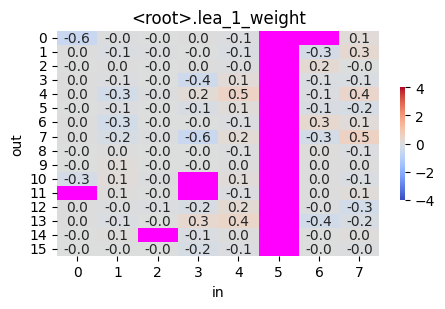

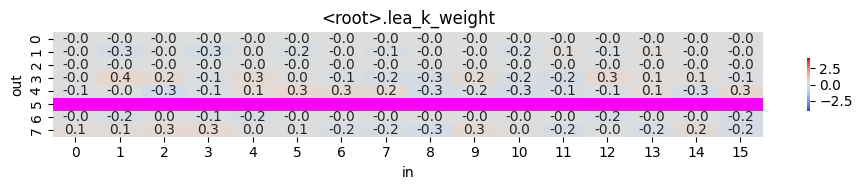

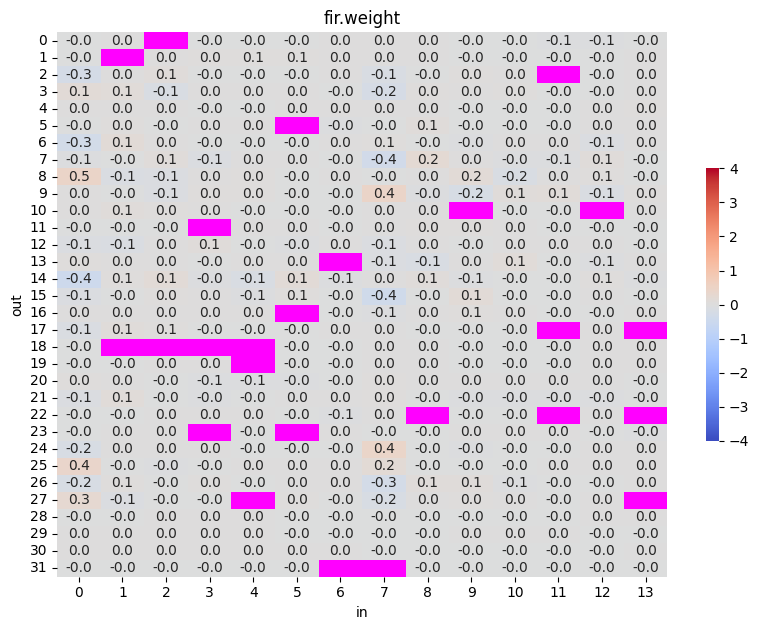

In [16]:
prunning.log_layerwise_sparsity(pleann_model)
plotting.plot_weight_heatmaps(pleann_model, vmin=-4, vmax=4)

Metrics

In [19]:
nmse_after_pa = metrics.compute_nmse(y_val_pa, container.val_output_target)

print(f"NMSE на выходе усилителя (без DPD): {nmse_after_pa:.2f} db")

# print(f"NMSE на выходе усилителя (DLA DPD): {nmse_dla:.2f} db")

# print(f"NMSE на выходе усилителя (ILA DPD): {nmse_ila:.2f} db")

print(f"NMSE на выходе усилителя (ILC DPD): {nmse_ilc:.2f} db")

print(f"NMSE на выходе усилителя (ILC DPD): {nmse_ilc_prune:.2f} db")



NMSE на выходе усилителя (без DPD): -9.46 db
NMSE на выходе усилителя (ILC DPD): -48.88 db
NMSE на выходе усилителя (ILC DPD): -47.93 db


In [20]:
x_val_acpr = metrics.calculate_acpr(container.val_input, acpr_meter)
y_val_acpr = metrics.calculate_acpr(container.val_output, acpr_meter)
y_val_pa_acpr = metrics.calculate_acpr(y_val_pa, acpr_meter)
y_val_target_acpr = metrics.calculate_acpr(container.val_output_target, acpr_meter)

# y_lin_dla_acpr = metrics.calculate_acpr(y_val_dla, acpr_meter)
# y_lin_ila_acpr = metrics.calculate_acpr(y_val_ila, acpr_meter)
y_lin_ilc_acpr = metrics.calculate_acpr(y_val_ilc, acpr_meter)

print(f"x_val_acpr: {x_val_acpr[0]:.2f} {x_val_acpr[1]:.2f}")
print(f"y_val_acpr: {y_val_acpr[0]:.2f} {y_val_acpr[1]:.2f}")
print(f"y_val_pa_acpr: {y_val_pa_acpr[0]:.2f} {y_val_pa_acpr[1]:.2f}")
print(f"y_val_target_acpr: {y_val_target_acpr[0]:.2f} {y_val_target_acpr[1]:.2f}")

# print(f"lin_dla_acpr: {y_lin_dla_acpr[0]:.2f} {y_lin_dla_acpr[1]:.2f}")
# print(f"lin_ila_acpr: {y_lin_ila_acpr[0]:.2f} {y_lin_ila_acpr[1]:.2f}")
print(f"lin_ilc_acpr: {y_lin_ilc_acpr[0]:.2f} {y_lin_ilc_acpr[1]:.2f}")


x_val_acpr: -71.27 -71.27
y_val_acpr: -41.15 -40.69
y_val_pa_acpr: -41.20 -40.75
y_val_target_acpr: -89.06 -89.06
lin_ilc_acpr: -61.76 -61.28


In [21]:
nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

u_k_acpr = metrics.calculate_acpr(u_k_val, acpr_meter)
u_k_pa_acpr = metrics.calculate_acpr(u_k_pa, acpr_meter)

print(f"u_k_acpr: {u_k_acpr}")
print(f"u_k_pa_acpr: {u_k_pa_acpr}")

NMSE на выходе усилителя (ILC): -70.82 db
u_k_acpr: [-39.18398225 -40.59284331]
u_k_pa_acpr: [-81.42989625 -79.96120902]


Spectrum

In [22]:
window_size = 50

freqs, spectrum_y_in = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_out = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_target = metrics.power_spectrum(container.val_output_target, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_dpd_dla = metrics.power_spectrum(y_dpd_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ila = metrics.power_spectrum(y_dpd_ila, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_dpd_ilc = metrics.power_spectrum(y_dpd_ilc, container.input_signal_fs, container.nperseg, window_size)

# _, spectrum_y_val_dla = metrics.power_spectrum(y_val_dla, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_val_ila = metrics.power_spectrum(y_val_ila, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_ilc = metrics.power_spectrum(y_val_ilc, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_ilc_prune = metrics.power_spectrum(y_val_ilc_prune, container.input_signal_fs, container.nperseg, window_size)


# _, spectrum_u_k = metrics.power_spectrum(u_k_val, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, container.input_signal_fs, container.nperseg, window_size)

c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


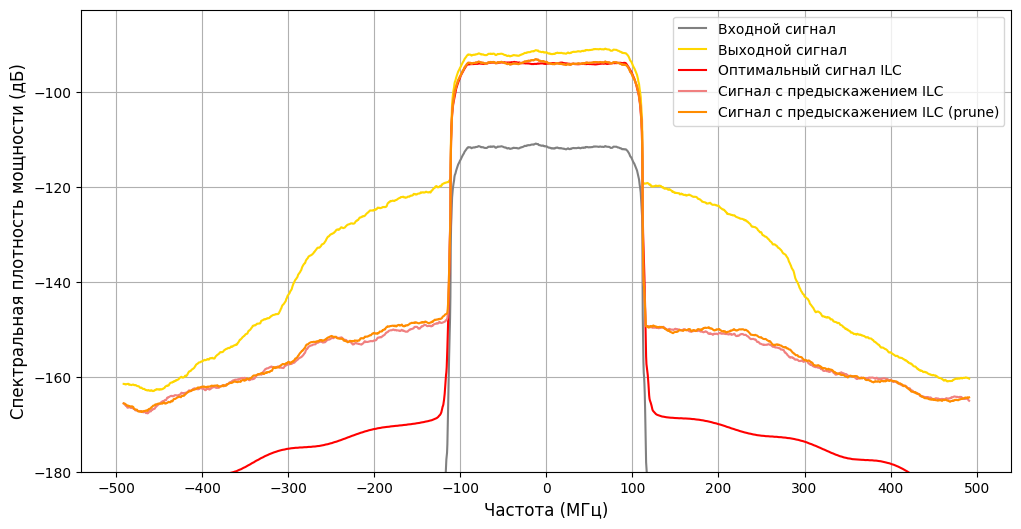

In [23]:
# построение спектра

xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_y_in, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_u_k_pa, color='red', label='Оптимальный сигнал ILC')
# plt.plot(freqs / 1e6, spectrum_y_val_dla, color='darkorange', label='Сигнал с предыскажением DLA')
# plt.plot(freqs / 1e6, spectrum_y_val_ila, color='limegreen', label='Сигнал с предыскажением ILA')
plt.plot(freqs / 1e6, spectrum_y_val_ilc, color='lightcoral', label='Сигнал с предыскажением ILC')
plt.plot(freqs / 1e6, spectrum_y_val_ilc_prune, color='darkorange', label='Сигнал с предыскажением ILC (prune)')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.ylim(bottom=-180)
plt.grid()
plt.show()



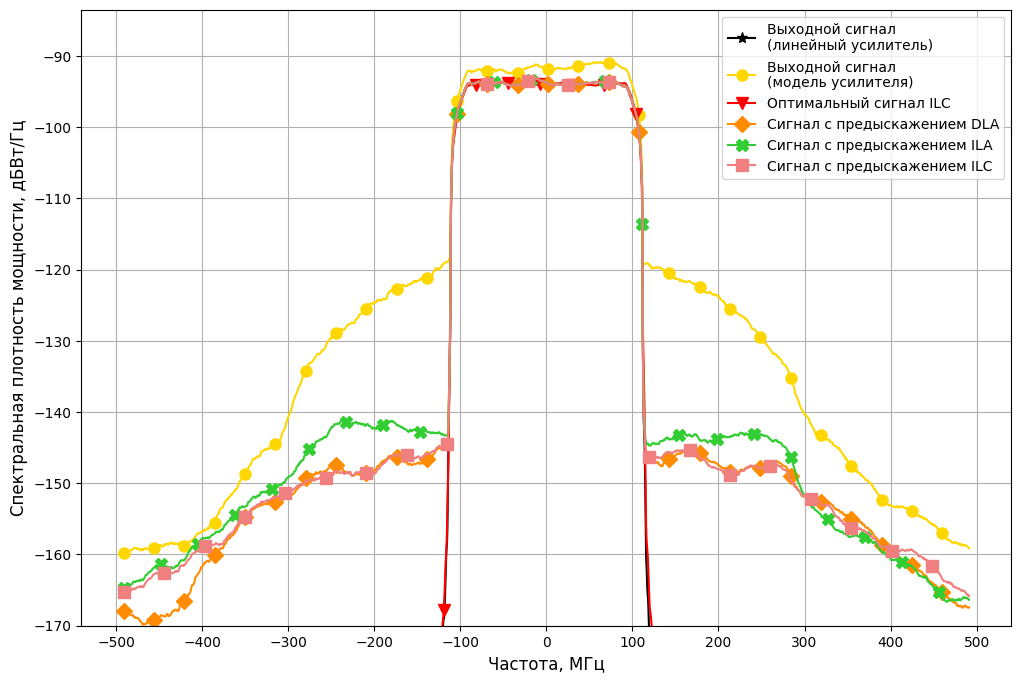

In [19]:

xlabel="Частота, МГц"
ylabel= "Спектральная плотность мощности, дБВт/Гц"
fontsize = 12
figsize=(12, 8)
markersize=8

plt.figure(figsize=figsize)

# plt.plot(freqs / 1e6, spectrum_y_in, 
#          color='grey', label='Входной сигнал',marker = '*', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_target, 
         color='black', label='Выходной сигнал\n(линейный усилитель)',marker = '*', markevery=90, markersize=markersize)

plt.plot(freqs / 1e6, spectrum_y_val_pa, 
         color='gold', label='Выходной сигнал\n(модель усилителя)', marker='o', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_u_k_pa, 
         color='red', label='Оптимальный сигнал ILC', marker='v', markevery=95, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_dla, 
         color='darkorange', label='Сигнал с предыскажением DLA', marker='D', markevery=90, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_ila, 
         color='limegreen', label='Сигнал с предыскажением ILA', marker='X', markevery=110, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_ilc, 
         color='lightcoral', label='Сигнал с предыскажением ILC', marker='s', markevery=120, markersize=markersize)


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.ylim(bottom=-170)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


AM/AM & AM/PM

In [20]:
y_in_am_am, y_out_am_am = metrics.calculate_am_am(container.val_input, container.val_output)
y_in_am_pm, y_in_phase_am_pm = metrics.calculate_am_pm(container.val_input, container.val_output)

_, y_pa_am_am = metrics.calculate_am_am(container.val_input, y_val_pa)
_, y_pa_phase_am_pm = metrics.calculate_am_pm(container.val_input, y_val_pa)

_, y_val_target_am_am = metrics.calculate_am_am(container.val_input, container.val_output_target)
_, y_val_target_phase_am_pm = metrics.calculate_am_pm(container.val_input, container.val_output_target)

# x_in_am_am, u_k_am_am = metrics.calculate_am_am(x_train, u_k)
# x_in_am_pm, u_k_phase_am_pm = metrics.calculate_am_pm(x_train, u_k)

# _, u_k_pa_am_am = metrics.calculate_am_am(x_train, u_k_pa)
# _, u_k_pa_phase_am_pm = metrics.calculate_am_pm(x_train, u_k_pa)

#linearized
_, y_val_dla_am_am = metrics.calculate_am_am(container.val_input, y_val_dla)
_, y_val_dla_phase_am_pm = metrics.calculate_am_pm(container.val_input, y_val_dla)

_, y_val_ila_am_am = metrics.calculate_am_am(container.val_input, y_val_ila)
_, y_val_ila_phase_am_pm = metrics.calculate_am_pm(container.val_input, y_val_ila)

_, y_val_ilc_am_am = metrics.calculate_am_am(container.val_input, y_val_ilc)
_, y_val_ilc_phase_am_pm = metrics.calculate_am_pm(container.val_input, y_val_ilc)


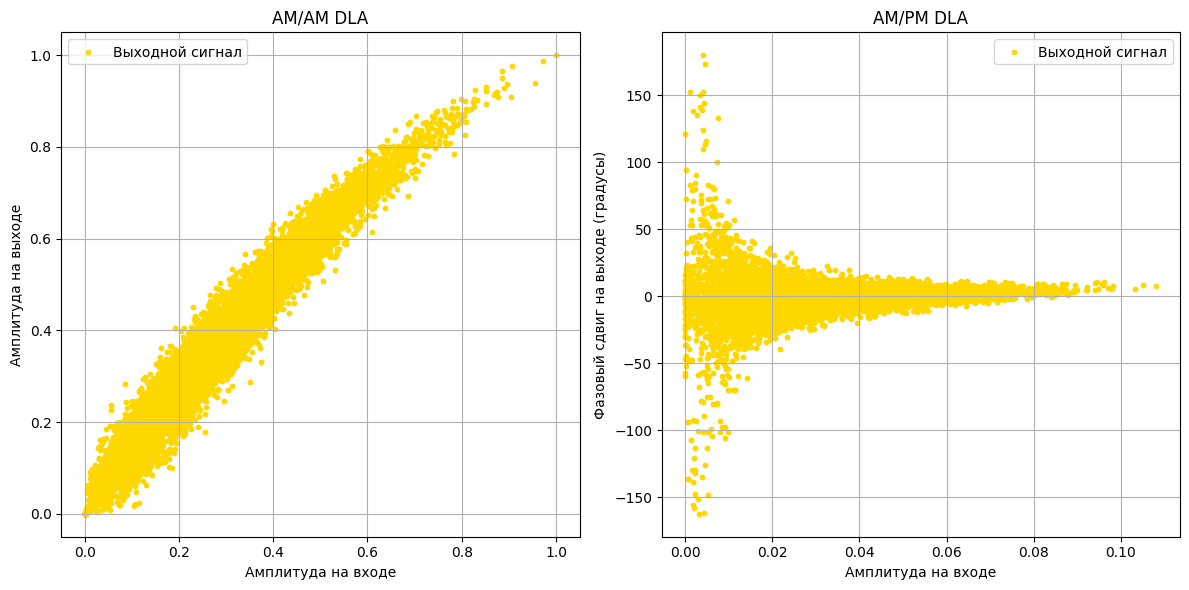

In [21]:
y_in_am_am, y_out_am_am = metrics.calculate_am_am(container.val_input, container.val_output)
y_in_am_pm, y_in_phase_am_pm = metrics.calculate_am_pm(container.val_input, container.val_output)

am_am_data = [
    (y_in_am_am, y_out_am_am, 'gold', 'Выходной сигнал'),
]

am_pm_data = [
    (y_in_am_pm, y_in_phase_am_pm, 'gold', 'Выходной сигнал'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM DLA", "AM/PM DLA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)



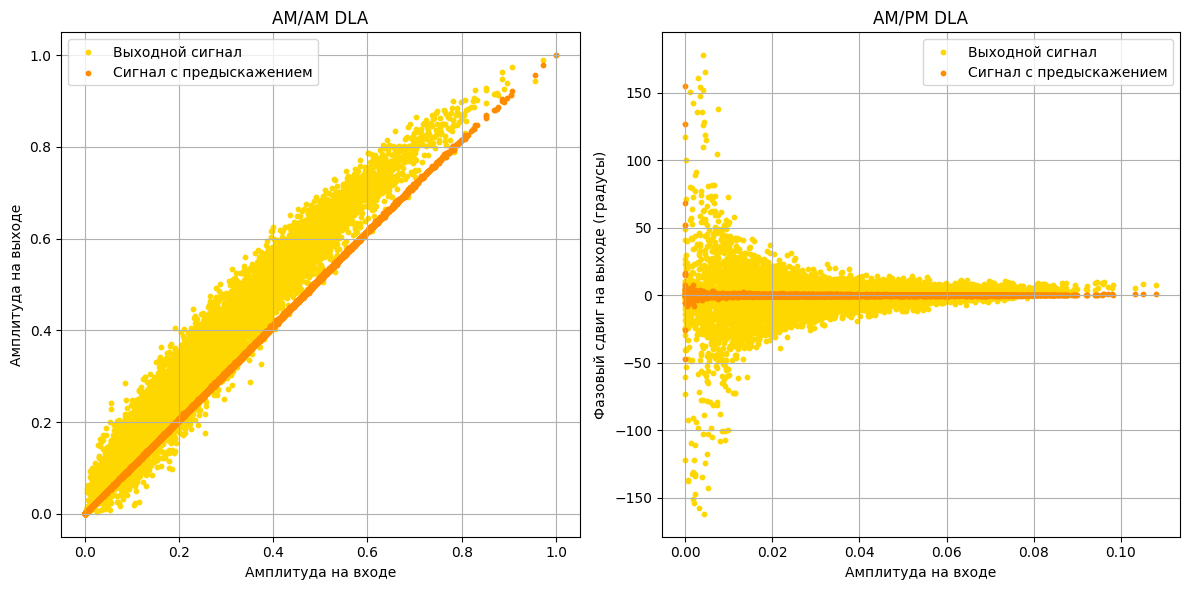

In [22]:
#DLA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_dla_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_val_dla_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_dla_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM DLA", "AM/PM DLA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)



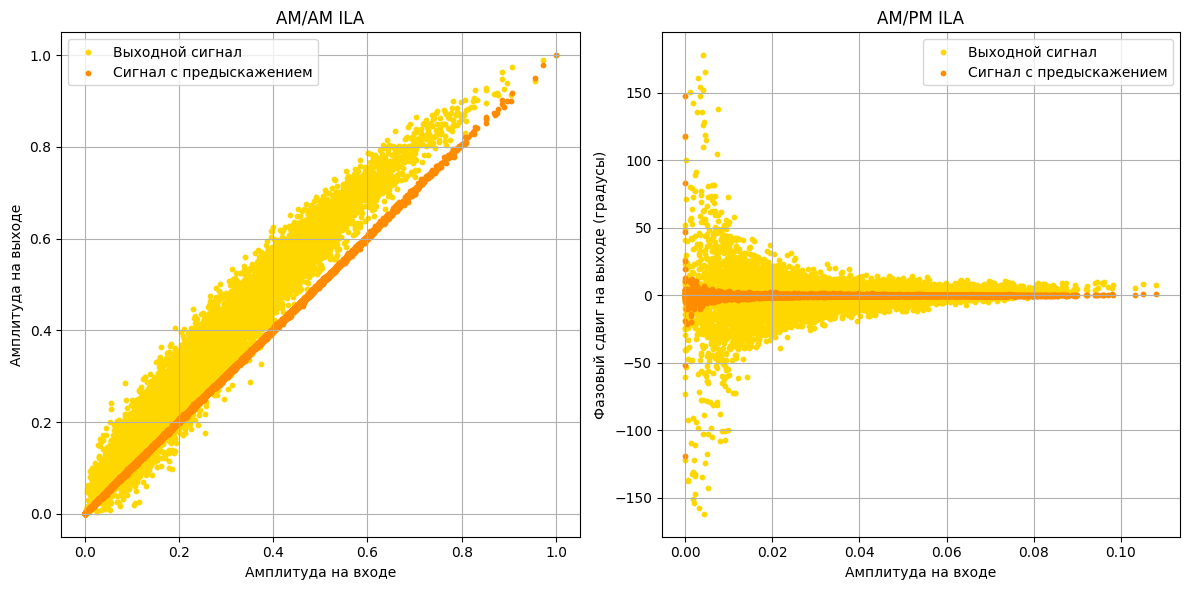

In [23]:
#ILA

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_val_ila_am_am, 'magenta', 'Сигнал на выходе DPD'),
    (y_in_am_am, y_val_ila_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_ila_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILA", "AM/PM ILA"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


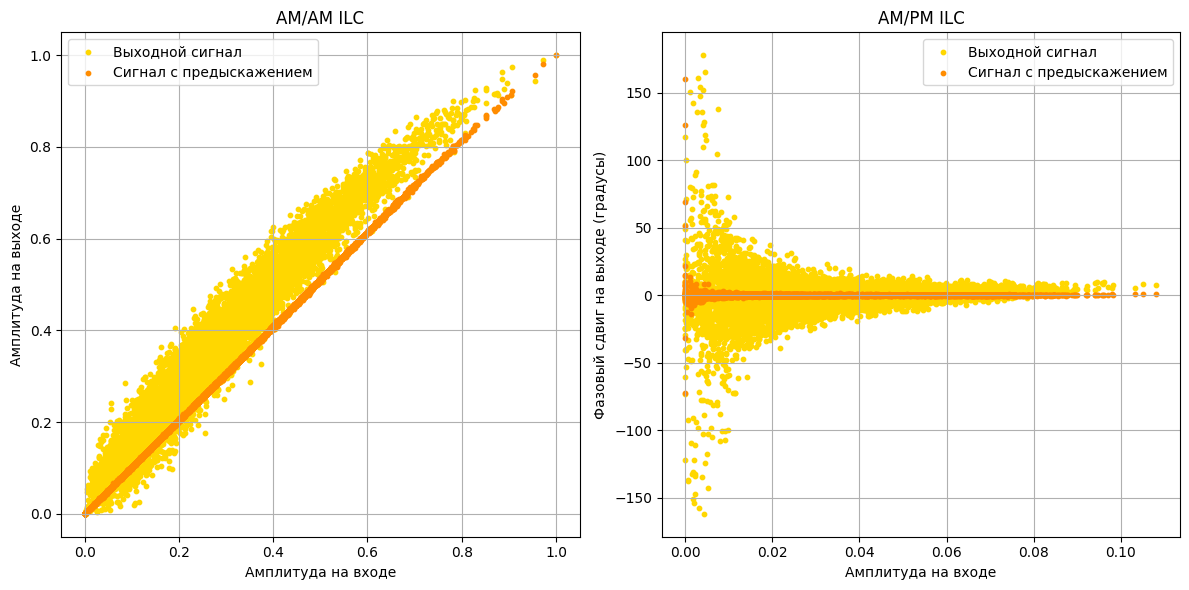

In [39]:
#ILC

am_am_data = [
    (y_in_am_am, y_pa_am_am, 'gold', 'Выходной сигнал'),
    # (y_in_am_am, y_dpd_ilc_grad_am_am, 'magenta', 'Сигнал на выходе корректора'),
    (y_in_am_am, y_val_ilc_am_am, 'darkorange', 'Сигнал с предыскажением'),
]

am_pm_data = [
    (y_in_am_pm, y_pa_phase_am_pm, 'gold', 'Выходной сигнал'),
    (y_in_am_pm, y_val_ilc_phase_am_pm, 'darkorange', 'Сигнал с предыскажением'),
]

plotting.plot_am_am_pm(
    am_am_data=am_am_data,
    am_pm_data=am_pm_data,
    figsize=(12, 6),
    titles=("AM/AM ILC", "AM/PM ILC"),
    xlabels=("Амплитуда на входе", "Амплитуда на входе"),
    ylabels=("Амплитуда на выходе", "Фазовый сдвиг на выходе (градусы)")
)


Add noise

In [32]:
snr_range = list(range(20, 61, 10))

epochs = 10
lr = 0.01
num_realizations = 500

snr_params = params.make_snr_params(
    snr_range=snr_range,
    num_realizations=num_realizations,
    fs=fs,
    bw_main_ch=bw_main_ch,
    epochs=epochs,
    learning_rate=lr,
    acpr_meter=acpr_meter,
    pa_model=pa_model,
    gain=gain
)

gmp_degree = 5
gmp_params = {"gmp_degree": gmp_degree}

snr_metrics_runner = pipelines.SnrPipeline(base_model=BatchGMP, 
                                           input_model_params=gmp_params, 
                                           data_dict=data, 
                                           snr_params=snr_params)

In [33]:
snr_metrics_runner.run_dla_noise()

SNR: 20
===Start training===
Epoch 0000 — train_loss: 0.218147, val_loss: 0.022959, val_NMSE: -15.31
Epoch 0001 — train_loss: 0.018544, val_loss: 0.015924, val_NMSE: -16.90
Epoch 0002 — train_loss: 0.015232, val_loss: 0.014882, val_NMSE: -17.19
Epoch 0003 — train_loss: 0.014828, val_loss: 0.015034, val_NMSE: -17.15
Epoch 0004 — train_loss: 0.014858, val_loss: 0.015014, val_NMSE: -17.16
Epoch 0005 — train_loss: 0.014799, val_loss: 0.014886, val_NMSE: -17.19
Epoch 0006 — train_loss: 0.014820, val_loss: 0.014992, val_NMSE: -17.16
Epoch 0007 — train_loss: 0.014843, val_loss: 0.014892, val_NMSE: -17.19
Epoch 0008 — train_loss: 0.014847, val_loss: 0.015162, val_NMSE: -17.11
Epoch 0009 — train_loss: 0.014832, val_loss: 0.014588, val_NMSE: -17.28
===Training complete===
Выполнение заняло: 0:02:54
SNR: 30
===Start training===
Epoch 0000 — train_loss: 0.472684, val_loss: 0.010352, val_NMSE: -18.77
Epoch 0001 — train_loss: 0.005322, val_loss: 0.002467, val_NMSE: -25.00
Epoch 0002 — train_loss: 0.

KeyboardInterrupt: 

In [ ]:
snr_metrics_runner.run_ila_noise()

SNR: 20
===Start training===
Epoch 0000 — train_loss: 0.059848, val_loss: 0.081936, val_NMSE: -1.76
Epoch 0100 — train_loss: 0.001612, val_loss: 0.001666, val_NMSE: -18.67
Epoch 0200 — train_loss: 0.001570, val_loss: 0.001626, val_NMSE: -18.78
Epoch 0300 — train_loss: 0.001572, val_loss: 0.001608, val_NMSE: -18.83
Epoch 0400 — train_loss: 0.001557, val_loss: 0.001562, val_NMSE: -18.95
Epoch 0499 — train_loss: 0.001543, val_loss: 0.001567, val_NMSE: -18.94
Время обучения: 0:01:14
===Training complete===
SNR: 25
===Start training===
Epoch 0000 — train_loss: 0.059314, val_loss: 0.097127, val_NMSE: -1.02
Epoch 0100 — train_loss: 0.000611, val_loss: 0.000626, val_NMSE: -22.92
Epoch 0200 — train_loss: 0.000581, val_loss: 0.000595, val_NMSE: -23.14
Epoch 0300 — train_loss: 0.000569, val_loss: 0.000595, val_NMSE: -23.15
Epoch 0400 — train_loss: 0.000564, val_loss: 0.000592, val_NMSE: -23.17
Epoch 0499 — train_loss: 0.000557, val_loss: 0.000590, val_NMSE: -23.18
Время обучения: 0:01:14
===Train

In [ ]:
snr_metrics_runner.run_ilc_noise()

SNR: 20
Epoch [0/500], Loss: 0.05481655150651932
Epoch [100/500], Loss: 0.018765931949019432
Epoch [200/500], Loss: 0.014988327398896217
Epoch [300/500], Loss: 0.014843262732028961
Epoch [400/500], Loss: 0.014706596732139587
Epoch [499/500], Loss: 0.014754110015928745
Время расчёта ilc_signal: 0:01:14
===Start training===
Epoch 0000 — train_loss: 0.035044, val_loss: 0.028912, val_NMSE: -3.81
Epoch 0100 — train_loss: 0.000031, val_loss: 0.000031, val_NMSE: -33.49
Epoch 0200 — train_loss: 0.000021, val_loss: 0.000020, val_NMSE: -35.31
Epoch 0300 — train_loss: 0.000018, val_loss: 0.000018, val_NMSE: -35.93
Epoch 0400 — train_loss: 0.000017, val_loss: 0.000017, val_NMSE: -36.21
Epoch 0499 — train_loss: 0.000016, val_loss: 0.000016, val_NMSE: -36.35
Время обучения: 0:00:58
===Training complete===
SNR: 25
Epoch [0/500], Loss: 0.03817254304885864
Epoch [100/500], Loss: 0.006577697116881609
Epoch [200/500], Loss: 0.004973146133124828
Epoch [300/500], Loss: 0.004793424159288406
Epoch [400/500],

In [56]:
results = snr_metrics_runner.get_results()

snr_range = results["snr_range"]

nmse_dla_list = results["dla"]["nmse"]
acpr_left_dla_list = results["dla"]["acpr_left"]
acpr_right_dla_list = results["dla"]["acpr_right"]

nmse_ila_list = results["ila"]["nmse"]
acpr_left_ila_list = results["ila"]["acpr_left"]
acpr_right_ila_list = results["ila"]["acpr_right"]

nmse_ilc_list = results["ilc"]["nmse"]
acpr_left_ilc_list = results["ilc"]["acpr_left"]
acpr_right_ilc_list = results["ilc"]["acpr_right"]

nmse_uk_list = results["uk"]["nmse"]
acpr_left_uk_list = results["uk"]["acpr_left"]
acpr_right_uk_list = results["uk"]["acpr_right"]

In [57]:
print(f"snr_range = {snr_range}")
print()

print(f"nmse_dla_list = {(nmse_dla_list)}")
print(f"acpr_left_dla_list = {acpr_left_dla_list}")
print(f"acpr_right_dla_list = {acpr_right_dla_list}")
print()

print(f"nmse_ila_list = {nmse_ila_list}")
print(f"acpr_left_ila_list = {acpr_left_ila_list}")
print(f"acpr_right_ila_list = {acpr_right_ila_list}")
print()

print(f"nmse_ilc_list = {nmse_ilc_list}")
print(f"acpr_left_ilc_list = {acpr_left_ilc_list}")
print(f"acpr_right_ilc_list = {acpr_right_ilc_list}")
print()

print(f"nmse_uk_list = {nmse_uk_list}")
print(f"acpr_left_uk_list = {acpr_left_uk_list}")
print(f"acpr_right_uk_list = {acpr_right_uk_list}")

snr_range = [20, 25, 30, 35, 40, 45, 50, 55, 60]

nmse_dla_list = [-17.148632049560547, -22.024913787841797, -26.938125610351562, -31.83021354675293, -36.51686096191406, -40.62764358520508, -43.64088821411133, -45.28367233276367, -45.97032928466797]
acpr_left_dla_list = [np.float64(-20.02928768602456), np.float64(-24.982584759640396), np.float64(-29.94026217788973), np.float64(-34.790795872739075), np.float64(-39.38424284115534), np.float64(-43.27951405106335), np.float64(-45.91862097413965), np.float64(-47.333822464193716), np.float64(-47.83152138893719)]
acpr_right_dla_list = [np.float64(-20.042172905027773), np.float64(-25.000703280641286), np.float64(-29.94555560855832), np.float64(-34.80382540388212), np.float64(-39.38523604062279), np.float64(-43.28755626930241), np.float64(-45.98511389366253), np.float64(-47.36026912001858), np.float64(-47.90736568475759)]

nmse_ila_list = [-16.83725929260254, -21.696548461914062, -26.669509887695312, -31.488346099853516, -36.02500915527344, -39

In [ ]:
# # значения в виде списков чтобы не рассчитывать снова все значения

# snr_range = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]

# nmse_dla_list = [-17.154949188232422, -19.09251594543457, -21.044750213623047, -23.021923065185547, -25.002155303955078, -26.98126983642578, -28.954303741455078, -30.937488555908203, -32.90107345581055, -34.845218658447266, -36.755924224853516, -38.61607360839844, -40.426910400390625, -42.124752044677734, -43.687843322753906, -45.075897216796875, -46.248626708984375, -47.228172302246094, -47.92564010620117, -48.49229431152344, -48.84376907348633]
# acpr_left_dla_list = [np.float64(-20.032896621274734), np.float64(-22.002898276331), np.float64(-23.980167111262954), np.float64(-25.985284041461938), np.float64(-27.943916970011372), np.float64(-29.91541877521779), np.float64(-31.871352771576074), np.float64(-33.797012660383636), np.float64(-35.67219414298505), np.float64(-37.49542101433636), np.float64(-39.210372332336746), np.float64(-40.8129737284458), np.float64(-42.2611022976035), np.float64(-43.489963007240796), np.float64(-44.48969779871533), np.float64(-45.26628275458397), np.float64(-45.82507862711507), np.float64(-46.26964161953022), np.float64(-46.544344312319446), np.float64(-46.7247453176207), np.float64(-46.8625007497271)]
# acpr_right_dla_list = [np.float64(-20.03067217721715), np.float64(-22.023901072994782), np.float64(-23.999487986191852), np.float64(-25.990288997195552), np.float64(-27.97879723510448), np.float64(-29.93405882623138), np.float64(-31.885189566353002), np.float64(-33.83402270942291), np.float64(-35.73882672394366), np.float64(-37.591940638042516), np.float64(-39.35400356485398), np.float64(-41.02262823000135), np.float64(-42.529186070031216), np.float64(-43.87146478243156), np.float64(-44.98060385142986), np.float64(-45.87641689390573), np.float64(-46.57500010862354), np.float64(-47.01434234515064), np.float64(-47.360535320706695), np.float64(-47.54855205738099), np.float64(-47.716042344669965)]

# nmse_ila_list = [-17.14900016784668, -19.082727432250977, -21.0418701171875, -23.009443283081055, -24.970191955566406, -26.952104568481445, -28.929380416870117, -30.873485565185547, -32.79220199584961, -34.68447494506836, -36.50259017944336, -38.23097229003906, -39.86079025268555, -41.318084716796875, -42.59962463378906, -43.62651062011719, -44.414581298828125, -45.008975982666016, -45.430274963378906, -45.73917007446289, -45.99494552612305]
# acpr_left_ila_list = [np.float64(-20.023492672712504), np.float64(-22.00194266264846), np.float64(-23.982589695597863), np.float64(-25.971010353814368), np.float64(-27.954582475654398), np.float64(-29.883061513651946), np.float64(-31.84119207223084), np.float64(-33.741020731136594), np.float64(-35.59542076282507), np.float64(-37.389910008838555), np.float64(-39.05389357257544), np.float64(-40.57882064420808), np.float64(-41.87301807298115), np.float64(-43.028623797072676), np.float64(-43.97164913381233), np.float64(-44.47478498942156), np.float64(-45.094347042181134), np.float64(-45.44431979439592), np.float64(-45.6689972060291), np.float64(-45.81347702948893), np.float64(-45.919890365450364)]
# acpr_right_ila_list = [np.float64(-20.037619673095683), np.float64(-22.02154157779769), np.float64(-24.00141855357515), np.float64(-25.97407114783849), np.float64(-27.954493059455036), np.float64(-29.931848642514495), np.float64(-31.87500171448285), np.float64(-33.78634424089804), np.float64(-35.682854215253045), np.float64(-37.49031966564913), np.float64(-39.21893888309752), np.float64(-40.82172035769772), np.float64(-42.24376419843244), np.float64(-43.494933171804725), np.float64(-44.48705283113159), np.float64(-45.28125077526404), np.float64(-45.82150567692158), np.float64(-46.23586524416965), np.float64(-46.483727735029944), np.float64(-46.80989034343764), np.float64(-46.76467487891643)]

# nmse_ilc_list = [-17.161582946777344, -19.08861541748047, -21.052515029907227, -23.02472496032715, -25.0006103515625, -26.98052978515625, -28.957475662231445, -30.93657875061035, -32.8939208984375, -34.8338737487793, -36.754276275634766, -38.548091888427734, -40.303565979003906, -41.94981002807617, -43.43807601928711, -44.752685546875, -45.811702728271484, -46.68809509277344, -47.2928581237793, -47.732051849365234, -48.105037689208984]
# acpr_left_ilc_list = [np.float64(-20.04499601993586), np.float64(-22.000575773262312), np.float64(-24.005173164637622), np.float64(-25.975381528613166), np.float64(-27.948773007731976), np.float64(-29.904547380654257), np.float64(-31.83497348292303), np.float64(-33.76508347209344), np.float64(-35.63135714041884), np.float64(-37.43372467772184), np.float64(-39.14673797702895), np.float64(-40.682020346354115), np.float64(-42.074796748562314), np.float64(-43.25955583198558), np.float64(-44.172655984033355), np.float64(-44.92677486420471), np.float64(-45.42858744174152), np.float64(-45.81765459787905), np.float64(-46.0679249887625), np.float64(-46.22621768342928), np.float64(-46.348104813507604)]
# acpr_right_ilc_list = [np.float64(-20.055033821205793), np.float64(-22.02296109860739), np.float64(-24.011375645858735), np.float64(-25.989965909004713), np.float64(-27.974052697082097), np.float64(-29.94138650953073), np.float64(-31.89681741205028), np.float64(-33.840142017577605), np.float64(-35.730656379008416), np.float64(-37.598354712999864), np.float64(-39.381993008609946), np.float64(-41.00939897421255), np.float64(-42.49628648885533), np.float64(-43.81904566125652), np.float64(-44.926036747000865), np.float64(-45.77697004484083), np.float64(-46.456832260637114), np.float64(-46.9203740307759), np.float64(-47.219135964704975), np.float64(-47.42920449390439), np.float64(-47.62513932513492)]

# nmse_uk_list = [-17.094663619995117, -19.016490936279297, -20.960582733154297, -22.905410766601562, -24.86489486694336, -26.823619842529297, -28.778156280517578, -30.729806900024414, -32.679481506347656, -34.633670806884766, -36.5738410949707, -38.51299285888672, -40.44480514526367, -42.37684631347656, -44.29717254638672, -46.236045837402344, -48.150821685791016, -50.04896926879883, -51.969764709472656, -53.85963439941406, -55.72507858276367]
# acpr_left_uk_list = [np.float64(-19.99438441289194), np.float64(-21.9658512665871), np.float64(-23.945869167743208), np.float64(-25.92128162743692), np.float64(-27.9018250793472), np.float64(-29.857668613519994), np.float64(-31.830175197925897), np.float64(-33.76021792312188), np.float64(-35.677025441911994), np.float64(-37.586095603435375), np.float64(-39.42729918519659), np.float64(-41.22707557884934), np.float64(-42.936348574753275), np.float64(-44.508877373457345), np.float64(-45.93217114866118), np.float64(-47.16637553054871), np.float64(-48.16740369704331), np.float64(-48.992740555776834), np.float64(-49.56517529961033), np.float64(-50.01273812436431), np.float64(-50.31230743627908)]
# acpr_right_uk_list = [np.float64(-19.908159326520842), np.float64(-21.85695263610488), np.float64(-23.818630432812846), np.float64(-25.74280605561588), np.float64(-27.685123164021324), np.float64(-29.597578780431057), np.float64(-31.50956145186845), np.float64(-33.408043631235536), np.float64(-35.2641539488935), np.float64(-37.11290256809776), np.float64(-38.87993901305795), np.float64(-40.61697803065708), np.float64(-42.25138725427255), np.float64(-43.7730148204967), np.float64(-45.139205723386205), np.float64(-46.40286494928455), np.float64(-47.41226707888618), np.float64(-48.2239296586826), np.float64(-48.8718445889375), np.float64(-49.305717773680755), np.float64(-49.67857146555004)]

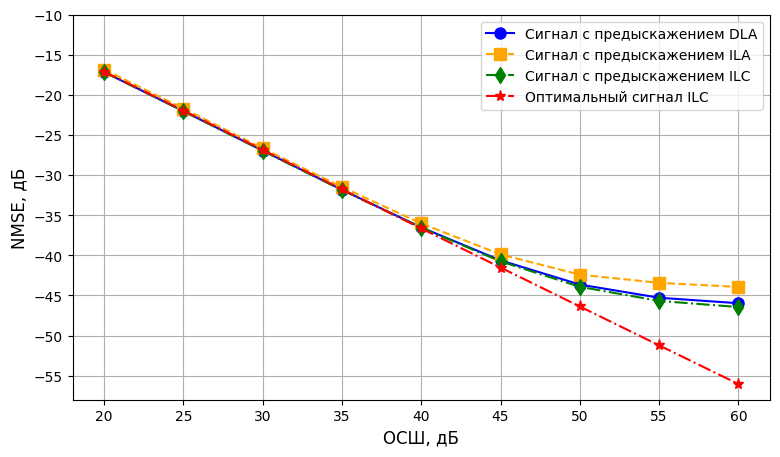

In [58]:
markersize = 8
plt.figure(figsize=(9, 5))
plt.plot(snr_range, nmse_dla_list,color='blue', linestyle='-', label="Сигнал с предыскажением DLA",
         marker='o', markersize=markersize)
plt.plot(snr_range, nmse_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA",
         marker='s', markersize=markersize)
plt.plot(snr_range, nmse_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC",
         marker='d', markersize=markersize)
plt.plot(snr_range, nmse_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC",
         marker='*', markersize=markersize)

plt.xlabel("ОСШ, дБ", fontsize=12)
plt.ylabel("NMSE, дБ", fontsize=12)
# plt.title("Зависимость NMSE от ОСШ")
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -9, 5))
plt.legend()
plt.grid(True)

plt.show()


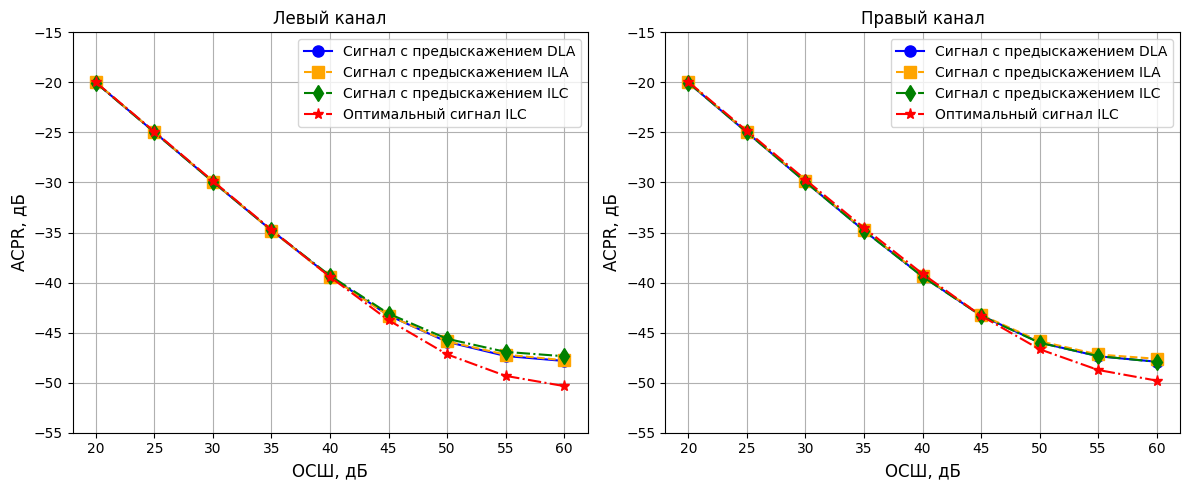

In [59]:
markersize=8
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(snr_range, acpr_left_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_left_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_left_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_left_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Левый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(snr_range, acpr_right_dla_list, color='blue', linestyle='-', label="Сигнал с предыскажением DLA", 
         marker='o', markersize=markersize)
plt.plot(snr_range, acpr_right_ila_list, color='orange', linestyle='--', label="Сигнал с предыскажением ILA", 
         marker='s', markersize=markersize)
plt.plot(snr_range, acpr_right_ilc_list, color='green', linestyle='-.', label="Сигнал с предыскажением ILC", 
         marker='d', markersize=markersize)
plt.plot(snr_range, acpr_right_uk_list, color='red', linestyle='-.', label="Оптимальный сигнал ILC", 
         marker='*', markersize=markersize)
plt.title('Правый канал', fontsize=12)
plt.xlabel('ОСШ, дБ', fontsize=12)
plt.ylabel('ACPR, дБ', fontsize=12)
plt.xticks(range(20, 61, 5))
plt.yticks(range(-55, -14, 5))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()